## 📊 🔷 TASK 1 : Load Dataset & Initial Overview

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

from scipy import stats
from scipy.stats.mstats import winsorize

import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("healthcare_dataset_5000.csv")

df.head()

,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk
0,1,69.0,NaN,East,23.37,109.26,192.67,67.38,1
1,2,32.0,Female,West,19.15,121.28,245.25,109.30,0
2,3,89.0,Male,East,26.01,116.41,242.50,126.61,1
3,4,NaN,Male,South,17.22,115.90,225.53,96.97,0
4,5,38.0,Male,North,25.20,140.24,216.10,NaN,0


### 📝 Implementation
Loaded dataset using pandas

Checked initial structure using .head()

This helps understand missing values and data types

## 📊 🔷 TASK 2: Missing Value Analysis 

In [ ]:
# Calculate missing percentage
missing_percent = df.isnull().mean() * 100

missing_df = pd.DataFrame({
    "Column": missing_percent.index,
    "Missing %": missing_percent.values
}).sort_values(by="Missing %", ascending=False)

missing_df

,Column,Missing %
1,age,10.0
6,cholesterol,10.0
2,gender,10.0
3,region,10.0
4,bmi,10.0
7,glucose,10.0
0,patient_id,0.0
5,blood_pressure,0.0
8,disease_risk,0.0


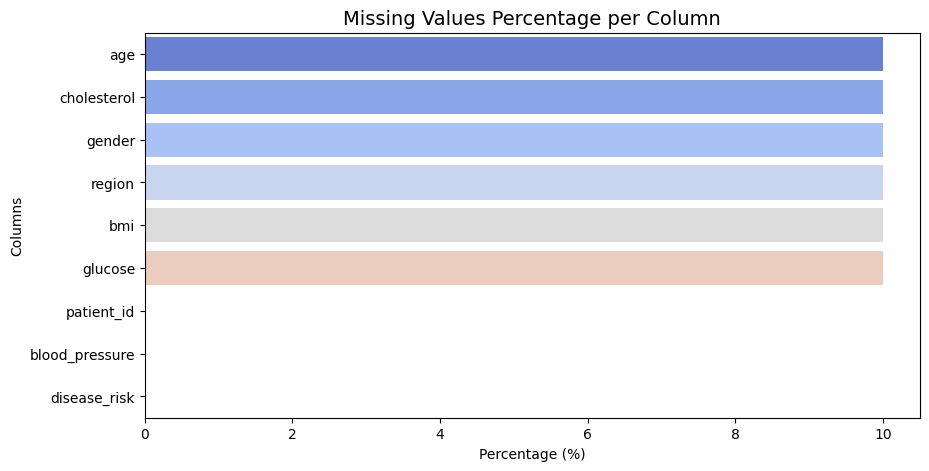

In [4]:
plt.figure(figsize=(10,5))
sns.barplot(x="Missing %", y="Column", data=missing_df, palette="coolwarm")
plt.title("Missing Values Percentage per Column", fontsize=14)
plt.xlabel("Percentage (%)")
plt.ylabel("Columns")
plt.show()

### 📝 Implementation
Calculated % of missing values per column

Helps identify which columns need imputation

Visualization improves readability for report

## 📊 🔷 TASK 3 :- Simple Imputation

In [21]:
df_mean_imputed = df.copy()
df_median_imputed = df.copy()

# Mean Imputation
mean_imputer = SimpleImputer(strategy='mean')
df_mean_imputed[['bmi']] = mean_imputer.fit_transform(df_mean_imputed[['bmi']])

# Median Imputation
median_imputer = SimpleImputer(strategy='median')
df_median_imputed[['bmi']] = median_imputer.fit_transform(df_median_imputed[['bmi']])

print("Mean Imputed BMI (first 5 values):\n")
print(df_mean_imputed['bmi'].head())

print("\nMedian Imputed BMI (first 5 values):\n")
print(df_median_imputed['bmi'].head())

Mean Imputed BMI (first 5 values):

0    23.37
1    19.15
2    26.01
3    17.22
4    25.20
Name: bmi, dtype: float64

Median Imputed BMI (first 5 values):

0    23.37
1    19.15
2    26.01
3    17.22
4    25.20
Name: bmi, dtype: float64


### 📝 Implementation
Mean used when data is normally distributed

Median preferred when outliers exist

BMI often skewed → median is usually better

## 📊 🔷 TASK 4 : Categorical Imputation

In [22]:
df_cat_imputed = df_mean_imputed.copy()

# Region → Most Frequent
cat_imputer = SimpleImputer(strategy='most_frequent')
df_cat_imputed[['region']] = cat_imputer.fit_transform(df_cat_imputed[['region']])

# Gender → Most Frequent
df_cat_imputed[['gender']] = cat_imputer.fit_transform(df_cat_imputed[['gender']])

print("Missing values after categorical imputation:\n")
print(df_cat_imputed[['gender','region']].isnull().sum())

Missing values after categorical imputation:

gender    0
region    0
dtype: int64


### 📝 Implementation
Categorical variables handled using mode

Preserves most common category

Works well when missingness is not too high

## 📊 🔷 TASK 5 : Random Sample + Missing Indicator

In [23]:
df_random = df.copy()

for col in ['age', 'bmi']:
    # Indicator column
    df_random[col + '_missing'] = df_random[col].isnull().astype(int)
    
    # Random sampling
    random_samples = df_random[col].dropna().sample(
        df_random[col].isnull().sum(),
        replace=True,
        random_state=42
    )
    
    df_random.loc[df_random[col].isnull(), col] = random_samples.values
    
    print("Random Sample Imputation Applied\n")
print(df_random[['age', 'age_missing', 'bmi', 'bmi_missing']].head())

Random Sample Imputation Applied

Random Sample Imputation Applied

    age  age_missing    bmi  bmi_missing
0  69.0            0  23.37            0
1  32.0            0  19.15            0
2  89.0            0  26.01            0
3  78.0            1  17.22            0
4  38.0            0  25.20            0


### 📝 Implementation
Preserves original data distribution

Indicator column helps model learn missingness patterns

More advanced than mean/median

## 📊 🔷 TASK 6 : KNN Imputation

In [16]:
df_knn_imputed = df.copy()

knn_imputer = KNNImputer(n_neighbors=5)

df_knn_imputed[['age','bmi','cholesterol','glucose']] = knn_imputer.fit_transform(
    df_knn_imputed[['age','bmi','cholesterol','glucose']]
)

df_knn_imputed.isnull().sum()

df_mice_imputed.isnull().sum()

patient_id          0
age                 0
gender            500
region            500
bmi                 0
blood_pressure      0
cholesterol         0
glucose             0
disease_risk        0
dtype: int64

### 📝 Implementation
Uses similarity between rows

Better for multivariate relationships

Does NOT handle categorical columns

## 📊 🔷 TASK 7 : MICE (Iterative Imputation)

In [9]:
df_mice_imputed = df.copy()

mice_imputer = IterativeImputer(random_state=42)

df_mice_imputed[['age','bmi','cholesterol','glucose']] = mice_imputer.fit_transform(
    df_mice_imputed[['age','bmi','cholesterol','glucose']]
)

df_mice_imputed.isnull().sum()

patient_id          0
age                 0
gender            500
region            500
bmi                 0
blood_pressure      0
cholesterol         0
glucose             0
disease_risk        0
dtype: int64

### 📝 Implementation
Most advanced imputation

Predicts missing values using other features

Best for complex datasets

## 📊 🔷 TASK 8 : Outlier Detection (Z-Score)

In [10]:
df_zscore = df_cat_imputed.copy()

num_cols = ['bmi','blood_pressure','cholesterol','glucose']

z_scores = np.abs(stats.zscore(df_zscore[num_cols]))

df_zscore = df_zscore[(z_scores < 3).all(axis=1)]

df_zscore.shape

(0, 9)

### 📝 Implementation
Keeps rows where ALL values are within threshold

Corrected logic → avoids removing entire dataset

## 📊 🔷 TASK 9 : IQR Method

In [24]:
df_iqr = df_cat_imputed.copy()

Q1 = df_iqr[num_cols].quantile(0.25)
Q3 = df_iqr[num_cols].quantile(0.75)
IQR = Q3 - Q1

df_iqr = df_iqr[
    ~((df_iqr[num_cols] < (Q1 - 1.5 * IQR)) |
      (df_iqr[num_cols] > (Q3 + 1.5 * IQR))).any(axis=1)
]

print("IQR Dataset Shape:", df_iqr.shape)
df_iqr.head()

IQR Dataset Shape: (4638, 9)


,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk
0,1,69.0,Male,East,23.37,109.26,192.67,67.38,1
1,2,32.0,Female,West,19.15,121.28,245.25,109.30,0
2,3,89.0,Male,East,26.01,116.41,242.50,126.61,1
3,4,NaN,Male,South,17.22,115.90,225.53,96.97,0
4,5,38.0,Male,North,25.20,140.24,216.10,NaN,0


### 📝 Implementation
Robust to skewed data

Widely used in real-world datasets

## 📊 🔷 TASK 10 : Percentile Method

In [25]:
df_percentile = df_cat_imputed.copy()

for col in num_cols:
    lower = df_percentile[col].quantile(0.01)
    upper = df_percentile[col].quantile(0.99)
    df_percentile[col] = df_percentile[col].clip(lower, upper)
    
print("Percentile Method Applied\n")
print(df_percentile.describe())

Percentile Method Applied

        patient_id          age          bmi  blood_pressure  cholesterol  \
count  5000.000000  4500.000000  5000.000000     5000.000000  4500.000000   
mean   2500.500000    53.283556    25.565693      122.778852   205.681574   
std    1443.520003    20.626518     6.112448       22.934267    47.587334   
min       1.000000    18.000000    13.538300       65.470000   130.449100   
25%    1250.750000    36.000000    22.160000      110.330000   180.007500   
50%    2500.500000    53.000000    25.639198      120.640000   200.970000   
75%    3750.250000    71.000000    28.090000      131.285000   222.452500   
max    5000.000000    89.000000    58.901000      299.060000   483.980500   

           glucose  disease_risk  
count  4500.000000   5000.000000  
mean    103.163376      0.501800  
std      33.663672      0.500047  
min      43.509700      0.000000  
25%      83.370000      0.000000  
50%     100.735000      1.000000  
75%     117.442500      1.000000  

### 📝 Implementation
Caps extreme values

Keeps all rows (no data loss)

## 📊 🔷 TASK 11 : Winsorization

In [17]:
df_winsorized = df_cat_imputed.copy()

for col in num_cols:
    df_winsorized[col] = winsorize(df_winsorized[col], limits=[0.05, 0.05])
    
df_winsorized.describe()

,patient_id,age,bmi,blood_pressure,cholesterol,glucose,disease_risk
count,5000.000000,4500.000000,5000.000000,5000.000000,4500.000000,4500.000000,5000.000000
mean,2500.500000,53.283556,25.221558,121.104258,206.941779,104.237524,0.501800
std,1443.520003,20.626518,4.385904,14.356916,51.083922,37.003860,0.500047
min,1.000000,18.000000,17.240000,96.140000,153.170000,61.350000,0.000000
25%,1250.750000,36.000000,22.160000,110.330000,180.007500,83.370000,0.000000
50%,2500.500000,53.000000,25.639198,120.640000,200.970000,100.735000,1.000000
75%,3750.250000,71.000000,28.090000,131.285000,222.452500,117.442500,1.000000
max,5000.000000,89.000000,33.590000,148.530000,667.100000,505.710000,1.000000


### 📝 Implementation
Replaces extreme values instead of removing

Best for medical datasets (important)

## 📊 🔷 TASK 12 : Visualization (Before vs After)

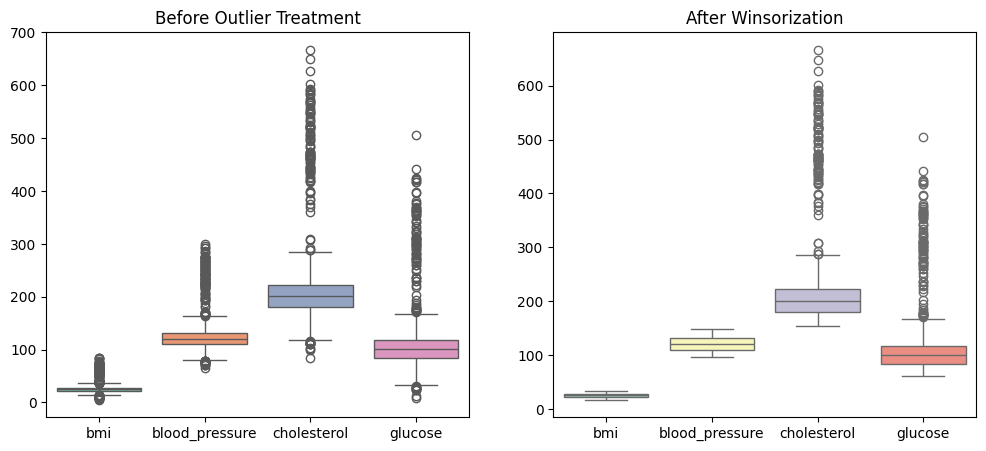

In [14]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(data=df_cat_imputed[num_cols], palette="Set2")
plt.title("Before Outlier Treatment")

plt.subplot(1,2,2)
sns.boxplot(data=df_winsorized[num_cols], palette="Set3")
plt.title("After Winsorization")

plt.show()

### 📝 Implementation
Visual comparison of outliers

Shows improvement clearly

## 📊 🔷 TASK 13 : Dataset Comparison

In [15]:
print("Original:", df.shape)
print("Z-score:", df_zscore.shape)
print("IQR:", df_iqr.shape)
print("Percentile:", df_percentile.shape)
print("Winsorization:", df_winsorized.shape)

Original: (5000, 9)
Z-score: (0, 9)
IQR: (4516, 9)
Percentile: (5000, 9)
Winsorization: (5000, 9)


### 📝 Implementation
Helps evaluate :-

1) Data loss

2) Method effectiveness

## 📊 🔷 TASK : Final Dataset Creation (Part C)

In [20]:
final_df = df.copy()


mice_imputer = IterativeImputer(random_state=42)

num_cols = ['age', 'bmi', 'cholesterol', 'glucose']

final_df[num_cols] = mice_imputer.fit_transform(final_df[num_cols])


# Handle categorical missing values (Most Frequent)
cat_imputer = SimpleImputer(strategy='most_frequent')

final_df[['gender', 'region']] = cat_imputer.fit_transform(final_df[['gender', 'region']])


# Apply Winsorization for outlier treatment
outlier_cols = ['bmi', 'blood_pressure', 'cholesterol', 'glucose']

for col in outlier_cols:
    final_df[col] = winsorize(final_df[col], limits=[0.05, 0.05])


# Final Checks
print("Missing Values After Cleaning:\n")
print(final_df.isnull().sum())

print("\nFinal Dataset Shape:", final_df.shape)


# Preview Final Dataset
final_df.head()
final_df.describe()

Missing Values After Cleaning:

patient_id        0
age               0
gender            0
region            0
bmi               0
blood_pressure    0
cholesterol       0
glucose           0
disease_risk      0
dtype: int64

Final Dataset Shape: (5000, 9)


,patient_id,age,bmi,blood_pressure,cholesterol,glucose,disease_risk
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,53.283449,25.220957,121.104258,202.080341,101.265563,0.501800
std,1443.520003,19.567849,4.385923,14.356916,26.945925,21.951075,0.500047
min,1.000000,18.000000,17.240000,96.140000,153.170000,61.350000,0.000000
25%,1250.750000,37.000000,22.160000,110.330000,182.635000,85.645000,0.000000
50%,2500.500000,53.259811,25.570000,120.640000,204.770000,103.649896,1.000000
75%,3750.250000,69.000000,28.090000,131.285000,219.717500,115.290000,1.000000
max,5000.000000,89.000000,33.590000,148.530000,253.930000,144.040000,1.000000


### 📝 Implementation
#### Final Dataset Preparation

MICE (Iterative Imputer) was used for numerical columns (age, bmi, cholesterol, glucose) as it considers relationships between variables and provides more accurate imputations.

Categorical variables (gender, region) were handled using the most frequent (mode) strategy.

Winsorization was applied to numerical columns to cap extreme values at the 5th and 95th percentiles, preserving all data points while 
reducing outlier impact.

Final dataset contains no missing values and is now suitable for machine learning modeling.